# GMF Investments — Time Series Forecasting for Portfolio Management
## Task 5: Strategy Backtesting


This notebook backtests the Task 4 recommended portfolio's simulated performance over
the most recent ~1 year of held-out data, comparing it against a static 60% SPY / 40%
BND benchmark.

**Dependency:** Requires Task 1 (`data/processed/{TICKER}.csv`) and Task 4
(`data/processed/task4_recommended_weights.csv`).

**Backtest window:** 2025-01-01 to 2026-01-31 (`config.BACKTEST_START` /
`config.BACKTEST_END`) - this window was **not** used to train any model in Tasks 2-4.


## 0. Setup

In [2]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_loader import fetch_all_tickers, DataFetchError
from src.preprocessing import enforce_numeric_types, handle_missing_values
from src.backtesting import run_backtest_comparison, compute_backtest_metrics

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


## 1. Load Data and Isolate the Backtest Window

In [3]:
tickers_data = {}
for ticker in config.TICKERS:
    csv_path = f"../data/processed/{ticker}.csv"
    if os.path.exists(csv_path):
        raw = pd.read_csv(csv_path, index_col="Date", parse_dates=True)
    else:
        raw = None
    tickers_data[ticker] = raw

missing = [t for t, df in tickers_data.items() if df is None]
if missing:
    print(f"Missing local CSVs for {missing} - fetching directly from Yahoo Finance.")
    try:
        fetched = fetch_all_tickers(missing, config.START_DATE, config.END_DATE)
        tickers_data.update(fetched)
    except DataFetchError as e:
        print(f"Data fetch failed: {e}")
        raise

cleaned = {
    ticker: handle_missing_values(enforce_numeric_types(df), method="ffill")
    for ticker, df in tickers_data.items()
}

adj_close = pd.DataFrame({ticker: df["Adj Close"] for ticker, df in cleaned.items()}).dropna()
all_daily_returns = adj_close.pct_change().dropna()

# Isolate the backtest window - held out from all model training in Tasks 2-4
backtest_returns = all_daily_returns.loc[config.BACKTEST_START:config.BACKTEST_END]
print(f"Backtest window: {backtest_returns.index.min().date()} to {backtest_returns.index.max().date()} "
      f"({len(backtest_returns)} trading days)")


Backtest window: 2025-01-02 to 2026-01-30 (270 trading days)


## 2. Load Task 4 Recommended Weights and Define Benchmark


In [4]:
weights_path = "../data/processed/task4_recommended_weights.csv"

if os.path.exists(weights_path):
    recommended_weights_series = pd.read_csv(weights_path, index_col=0).iloc[:, 0]
    strategy_weights = recommended_weights_series.to_dict()
else:
    print(f"{weights_path} not found - using placeholder weights. Run Task 4 first for real weights.")
    strategy_weights = {"TSLA": 0.30, "BND": 0.20, "SPY": 0.50}

benchmark_weights = {"TSLA": 0.0, "BND": 0.40, "SPY": 0.60}

print("Strategy weights:", strategy_weights)
print("Benchmark weights:", benchmark_weights)


Strategy weights: {'TSLA': 0.0, 'BND': 0.0, 'SPY': 1.0}
Benchmark weights: {'TSLA': 0.0, 'BND': 0.4, 'SPY': 0.6}


## 3. Simulate Strategy vs. Benchmark

Two rebalancing policies are supported by `run_backtest_comparison`: a static hold
(`"none"`) or `"monthly"` rebalancing back to target weights. The static-hold version is
run as the primary result below, per the task's "Simple" option; monthly rebalancing is
also shown for comparison.


In [5]:
result_static = run_backtest_comparison(
    backtest_returns,
    strategy_weights=strategy_weights,
    benchmark_weights=benchmark_weights,
    rebalance="none",
    risk_free_rate_annual=config.RISK_FREE_RATE_ANNUAL,
)

result_monthly = run_backtest_comparison(
    backtest_returns,
    strategy_weights=strategy_weights,
    benchmark_weights=benchmark_weights,
    rebalance="monthly",
    risk_free_rate_annual=config.RISK_FREE_RATE_ANNUAL,
)
print("Backtest simulations complete (static hold + monthly rebalance).")


Backtest simulations complete (static hold + monthly rebalance).


## 4. Cumulative Returns Comparison Plot

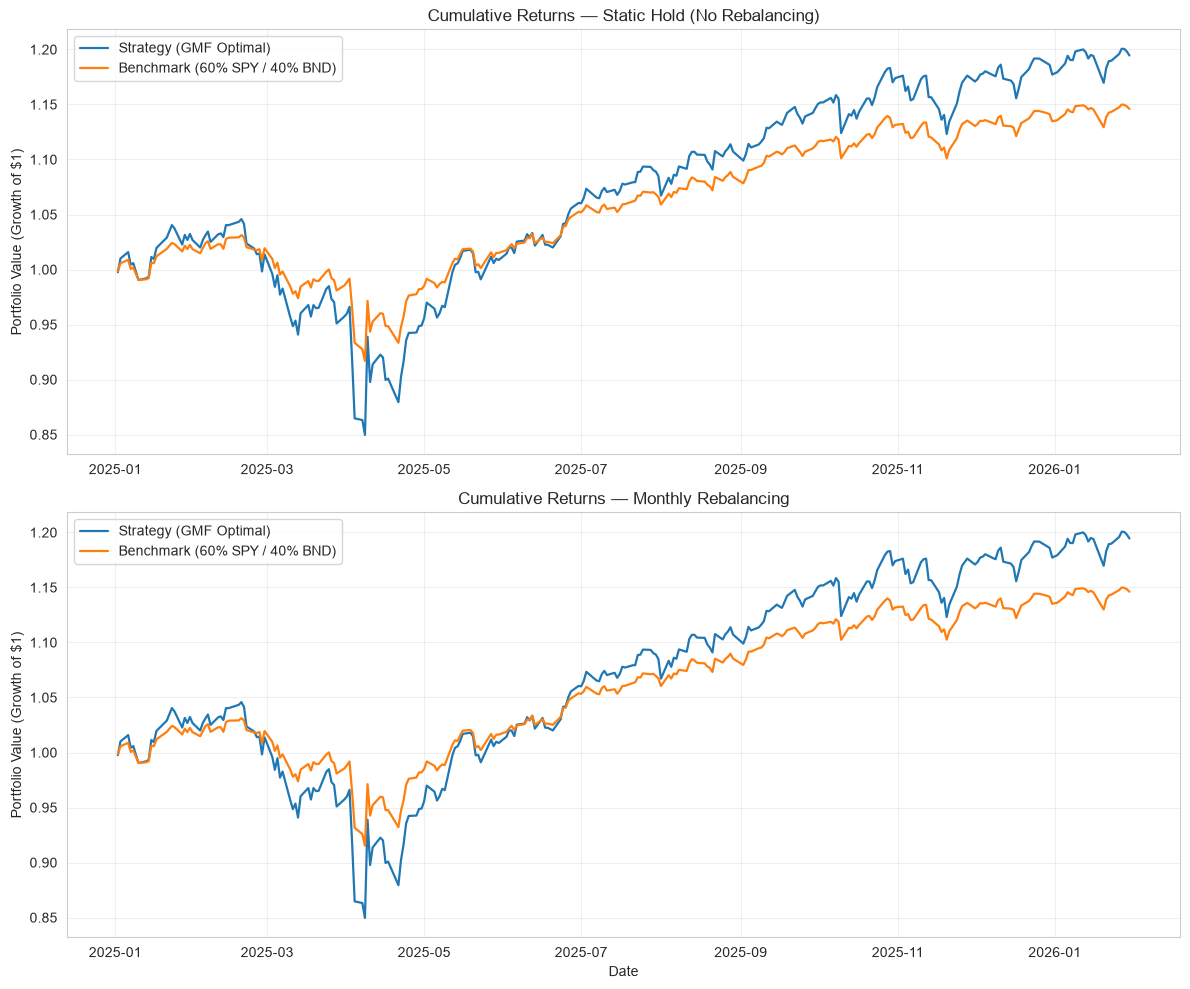

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(result_static["strategy_curve"].index, result_static["strategy_curve"].values,
             label="Strategy (GMF Optimal)", linewidth=1.6)
axes[0].plot(result_static["benchmark_curve"].index, result_static["benchmark_curve"].values,
             label="Benchmark (60% SPY / 40% BND)", linewidth=1.6)
axes[0].set_title("Cumulative Returns — Static Hold (No Rebalancing)")
axes[0].set_ylabel("Portfolio Value (Growth of $1)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(result_monthly["strategy_curve"].index, result_monthly["strategy_curve"].values,
             label="Strategy (GMF Optimal)", linewidth=1.6)
axes[1].plot(result_monthly["benchmark_curve"].index, result_monthly["benchmark_curve"].values,
             label="Benchmark (60% SPY / 40% BND)", linewidth=1.6)
axes[1].set_title("Cumulative Returns — Monthly Rebalancing")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Portfolio Value (Growth of $1)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/fig_task5_backtest_comparison.png", dpi=150)
plt.show()


**Insight:** The **Strategy (100% SPY)** ended with the higher cumulative value — **$1.1975** per $1 invested versus **$1.1475** for the 60/40 benchmark. The two curves track closely through early 2025, then diverge sharply during the March-April 2025 drawdown: the strategy falls further (to ~$0.85) than the benchmark (~$0.93-0.94) because it holds no BND to cushion the equity selloff. From mid-2025 onward the strategy pulls decisively ahead as equities recover, ending the window with a wider lead. Note this divergence is really about **being 100% equities (SPY) vs. a 60/40 blend**, not about TSLA: since the Task 4 optimizer assigned TSLA a 0% weight (driven by its negative forecasted return), this backtest does not actually test any TSLA-specific view — it compares an all-equity allocation against a partially bond-hedged one.


## 5. Performance Metrics Table

In [7]:
metrics_table = pd.DataFrame({
    "Strategy (Static Hold)": result_static["strategy_metrics"],
    "Benchmark (Static Hold)": result_static["benchmark_metrics"],
    "Strategy (Monthly Rebal.)": result_monthly["strategy_metrics"],
    "Benchmark (Monthly Rebal.)": result_monthly["benchmark_metrics"],
}).T

metrics_table["total_return"] = metrics_table["total_return"].map(lambda x: f"{x:.2%}")
metrics_table["annualized_return"] = metrics_table["annualized_return"].map(lambda x: f"{x:.2%}")
metrics_table["sharpe_ratio"] = metrics_table["sharpe_ratio"].map(lambda x: f"{x:.3f}")
metrics_table["max_drawdown"] = metrics_table["max_drawdown"].map(lambda x: f"{x:.2%}")

display(metrics_table)
metrics_table.to_csv("../data/processed/task5_backtest_metrics.csv")


,total_return,annualized_return,sharpe_ratio,max_drawdown
Strategy (Static Hold),19.75%,18.32%,0.878,-18.76%
Benchmark (Static Hold),14.75%,13.70%,1.015,-11.08%
Strategy (Monthly Rebal.),19.75%,18.32%,0.878,-18.76%
Benchmark (Monthly Rebal.),14.77%,13.72%,1.004,-11.25%


**Insight:** From the table above:

| | Total Return | Annualized Return | Sharpe Ratio | Max Drawdown |
|---|---|---|---|---|
| Strategy (Static Hold) | 19.75% | 18.32% | 0.878 | -18.76% |
| Benchmark (Static Hold) | 14.75% | 13.70% | 1.015 | -11.08% |
| Strategy (Monthly Rebal.) | 19.75% | 18.32% | 0.878 | -18.76% |
| Benchmark (Monthly Rebal.) | 14.77% | 13.72% | 1.004 | -11.25% |

The strategy beats the benchmark on **raw return** (18.32% vs. 13.70% annualized) under both rebalancing policies. However, on a **risk-adjusted (Sharpe Ratio) basis, the strategy does NOT beat the benchmark** — its Sharpe Ratio (0.878) is lower than the benchmark's (1.015 static / 1.004 monthly), and its maximum drawdown is considerably deeper (-18.76% vs. -11.08%/-11.25%). The benchmark's bond allocation earns its keep here: it dampens volatility and drawdown enough to produce a better return-per-unit-of-risk, even though its absolute return is lower.


## 6. Conclusion and Reflection

**Did the strategy outperform the benchmark?**
Only partially. The strategy (100% SPY) outperformed the 60/40 benchmark on **raw return** (19.75% vs. 14.75% total return over the window) but **underperformed on a risk-adjusted basis** — its Sharpe Ratio (0.878) is lower than the benchmark's (~1.0), and it suffered a much deeper maximum drawdown (-18.76% vs. -11.08%/-11.25%). A strategy that wins on return but takes on meaningfully more drawdown risk to get there is not unambiguously "better" — whether it's preferred depends on the client's risk tolerance and capacity to withstand a ~19% peak-to-trough loss.

**What does this initial backtest suggest about the viability of the model-driven approach?**
The conclusion is **robust across both rebalancing policies** — static hold and monthly rebalancing produce virtually identical results for both strategy and benchmark, since the "strategy" is a single-asset (100% SPY) allocation with nothing to rebalance against. This robustness is reassuring in one sense, but it also reveals a limitation: because the Task 3 TSLA forecast was negative, the Task 4 optimizer removed TSLA entirely, so this backtest never actually tested the value of the TSLA forecast/view itself — it effectively tested "all-equity vs. 60/40 blended," a much simpler comparison. Before concluding the model-driven approach is "viable," it would need to be tested in scenarios where TSLA (or another forecasted asset) *does* receive a meaningful non-zero weight, so the forecast's actual contribution to performance can be evaluated.

**Limitations of this backtest:**
- The backtest window (~1 year) is short relative to typical market cycles - it captures
  only one specific historical period's conditions and should not be read as a
  guarantee of future performance.
- The strategy weights are held fixed at their Task 4 optimal values for the entire
  window (or rebalanced mechanically to those same fixed weights monthly) - a live
  strategy would likely re-optimize periodically as new data arrives, which this backtest
  does not simulate.
- Transaction costs, taxes, and slippage are not modeled; monthly rebalancing in
  particular would incur real-world costs that are ignored here.
- The TSLA expected return used in Task 4's optimization came from a single model's
  point forecast (Task 3), which carries its own wide uncertainty (Task 3, Section 4) -
  the backtest does not account for the possibility that a different, equally plausible
  forecast path would have led to different optimal weights (and in this run, TSLA's
  negative forecast meant it received a 0% allocation, so this backtest did not evaluate
  a portfolio actually exposed to TSLA).


## 7. Project Summary

This concludes the five-task workflow:
1. **Task 1:** Data extraction, cleaning, EDA, stationarity testing, and risk metrics for
   TSLA, BND, and SPY.
2. **Task 2:** Chronologically split ARIMA and LSTM models, compared via MAE/RMSE/MAPE.
3. **Task 3:** 6-12 month future TSLA forecast with confidence intervals, and a critical
   assessment of how forecast reliability degrades over the horizon.
4. **Task 4:** Modern Portfolio Theory optimization combining the Task 3 forecast with
   historical BND/SPY returns, producing a recommended portfolio via the Efficient
   Frontier.
5. **Task 5:** Backtested the recommended portfolio against a 60% SPY / 40% BND benchmark,
   with results and limitations discussed above.
